In [2]:
from google.colab import files

uploaded = files.upload()

Saving student-por.csv to student-por.csv


In [3]:
import pandas as pd

df = pd.read_csv("student-por.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df.shape

(649, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [7]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [8]:
df = df.fillna(df.mean(numeric_only=True))

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

Regression

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2"
]

X = df[features]
y = df["G3"]

In [14]:
print(X.isnull().sum())
print(y.isnull().sum())

age           0
Medu          0
Fedu          0
traveltime    0
studytime     0
failures      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
dtype: int64
0


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
df = df.drop_duplicates()

Train/Test split

In [17]:
X = df[features]
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (519, 15)
Testing data: (130, 15)


Linear Regression

In [18]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [19]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [20]:
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
--------------------------
MAE : 0.7348086550074666
RMSE: 1.1664402826147429
R²  : 0.860477588128216


Actual vs Predicted graph

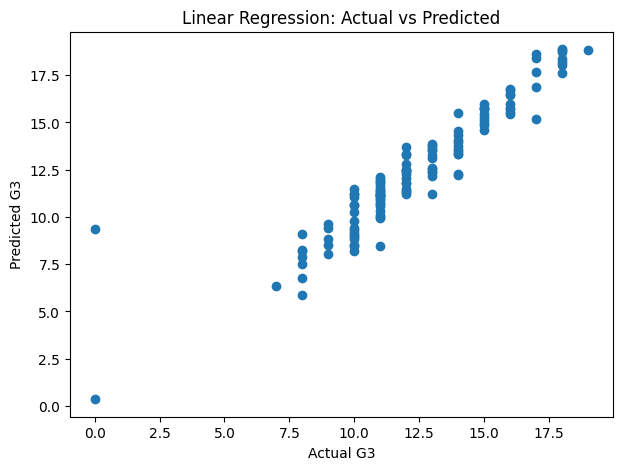

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, linear_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

Polynomial Regression

In [22]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [23]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

In [24]:
poly_mae = mean_absolute_error(y_test, poly_pred)

poly_rmse = np.sqrt(
    mean_squared_error(y_test, poly_pred)
)

poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial Regression Results")
print("------------------------------")
print("MAE :", poly_mae)
print("RMSE:", poly_rmse)
print("R²  :", poly_r2)

Polynomial Regression Results
------------------------------
MAE : 1.0203000861946903
RMSE: 1.5796717114661587
R²  : 0.744110398409574


Ridge Regression

In [25]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [26]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression Results
------------------------
MAE : 0.7347265840022826
RMSE: 1.1664387956951028
R²  : 0.8604779438403519


Lasso Regression

In [27]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

In [28]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Results")
print("------------------------")
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

Lasso Regression Results
------------------------
MAE : 0.7231592149417637
RMSE: 1.1588899653088973
R²  : 0.8622779872841508


Compare all four regression models

In [29]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MAE": [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae
    ],

    "RMSE": [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse
    ],

    "R2 Score": [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.734809,1.166440,0.860478
1,Polynomial Regression,1.020300,1.579672,0.744110
2,Ridge Regression,0.734727,1.166439,0.860478
3,Lasso Regression,0.723159,1.158890,0.862278


Compare R² scores graphically

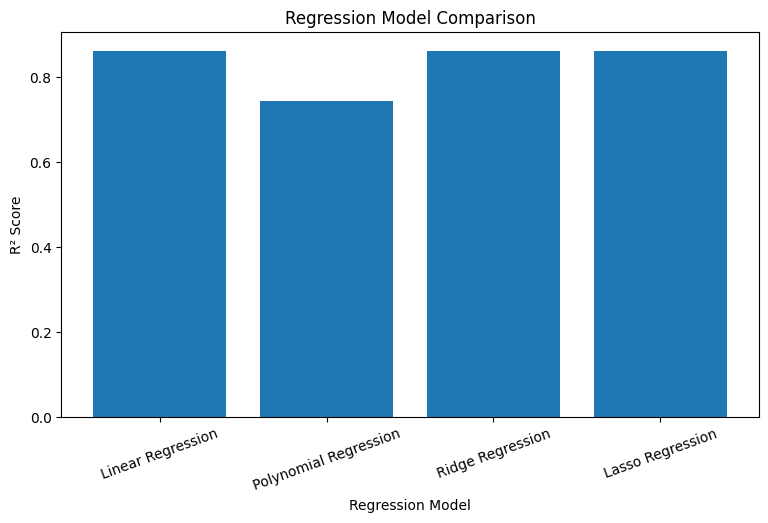

In [30]:
plt.figure(figsize=(9,5))

plt.bar(
    regression_results["Model"],
    regression_results["R2 Score"]
)

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison")

plt.xticks(rotation=20)

plt.show()

Compare RMSE

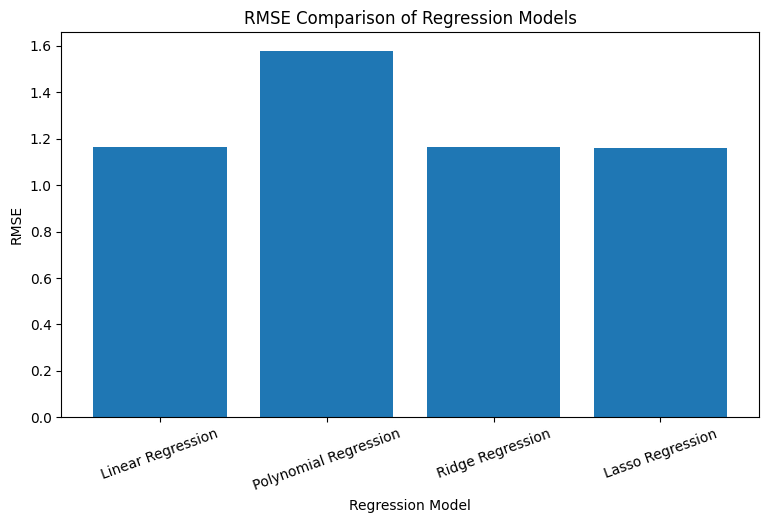

In [31]:
plt.figure(figsize=(9,5))

plt.bar(
    regression_results["Model"],
    regression_results["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")

plt.xticks(rotation=20)

plt.show()

Find the best regression model

In [32]:
best_model = regression_results.loc[
    regression_results["R2 Score"].idxmax()
]

print("Best Regression Model:")
print(best_model)

Best Regression Model:
Model       Lasso Regression
MAE                 0.723159
RMSE                 1.15889
R2 Score            0.862278
Name: 3, dtype: object


classification

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [34]:
df = pd.read_csv("student-por.csv", sep=";")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (649, 1)


,"school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3"
0,"GP,""F"",18,""U"",""GT3"",""A"",4,4,""at_home"",""teacher..."
1,"GP,""F"",17,""U"",""GT3"",""T"",1,1,""at_home"",""other"",..."
2,"GP,""F"",15,""U"",""LE3"",""T"",1,1,""at_home"",""other"",..."
3,"GP,""F"",15,""U"",""GT3"",""T"",4,2,""health"",""services..."
4,"GP,""F"",16,""U"",""GT3"",""T"",3,3,""other"",""other"",""h..."


In [35]:
features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2"
]

X = df[features]
y = df["Pass_Fail"]

KeyError: "None of [Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',\n       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],\n      dtype='object')] are in the [columns]"

Split the data

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

In [43]:
# Reload the original dataset
df = pd.read_csv("student-por.csv", sep=";")

print(df.shape)
print(df.columns.tolist())

(649, 1)
['school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3']


In [45]:
import pandas as pd
import numpy as np

df = pd.read_csv("student-por.csv")

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (649, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [46]:
# ==========================================
# CLASSIFICATION SETUP
# ==========================================

# Create Pass/Fail target
# G3 >= 10 = Pass
# G3 < 10  = Fail

df["Pass_Fail"] = np.where(df["G3"] >= 10, 1, 0)

# Features
features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2"
]

X_class = df[features]
y_class = df["Pass_Fail"]

print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

print("\nTarget classes:")
print(y_class.value_counts())

print("\nUnique classes:", y_class.unique())

X shape: (649, 15)
y shape: (649,)

Target classes:
Pass_Fail
1    549
0    100
Name: count, dtype: int64

Unique classes: [1 0]


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_class_scaled,
    y_train_class
)

logistic_pred = logistic_model.predict(
    X_test_class_scaled
)

print("Predicted classes:", np.unique(logistic_pred))

Predicted classes: [0 1]


In [48]:
logistic_accuracy = accuracy_score(y_test_class, logistic_pred)
logistic_precision = precision_score(y_test_class, logistic_pred)
logistic_recall = recall_score(y_test_class, logistic_pred)
logistic_f1 = f1_score(y_test_class, logistic_pred)

print("================================")
print("LOGISTIC REGRESSION RESULTS")
print("================================")

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nClassification Report:")

print(
    classification_report(
        y_test_class,
        logistic_pred,
        labels=[0, 1],
        target_names=["Fail", "Pass"]
    )
)

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8923076923076924
Precision: 0.9363636363636364
Recall   : 0.9363636363636364
F1 Score : 0.9363636363636364

Classification Report:
              precision    recall  f1-score   support

        Fail       0.65      0.65      0.65        20
        Pass       0.94      0.94      0.94       110

    accuracy                           0.89       130
   macro avg       0.79      0.79      0.79       130
weighted avg       0.89      0.89      0.89       130



KNN Classification

In [49]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [51]:
# ==========================================
# KNN CLASSIFICATION
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN
knn_model.fit(
    X_train_class_scaled,
    y_train_class
)

# Make predictions
knn_pred = knn_model.predict(
    X_test_class_scaled
)

# Evaluation
knn_accuracy = accuracy_score(
    y_test_class,
    knn_pred
)

knn_precision = precision_score(
    y_test_class,
    knn_pred
)

knn_recall = recall_score(
    y_test_class,
    knn_pred
)

knn_f1 = f1_score(
    y_test_class,
    knn_pred
)

print("================================")
print("KNN RESULTS")
print("================================")

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN RESULTS
Accuracy : 0.8615384615384616
Precision: 0.8833333333333333
Recall   : 0.9636363636363636
F1 Score : 0.9217391304347826


In [52]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_class,
        knn_pred,
        labels=[0, 1],
        target_names=["Fail", "Pass"]
    )
)


Classification Report:
              precision    recall  f1-score   support

        Fail       0.60      0.30      0.40        20
        Pass       0.88      0.96      0.92       110

    accuracy                           0.86       130
   macro avg       0.74      0.63      0.66       130
weighted avg       0.84      0.86      0.84       130



In [53]:
cm_knn = confusion_matrix(
    y_test_class,
    knn_pred
)

print("Confusion Matrix:")
print(cm_knn)

Confusion Matrix:
[[  6  14]
 [  4 106]]


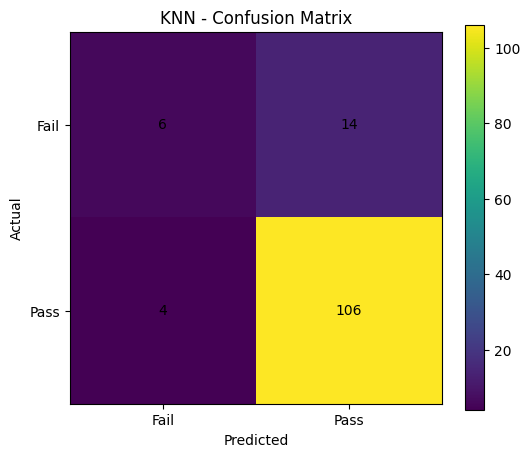

In [54]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_knn)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_knn[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [55]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall
    ],
    "F1 Score": [
        logistic_f1,
        knn_f1
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.892308,0.936364,0.936364,0.936364
1,KNN,0.861538,0.883333,0.963636,0.921739


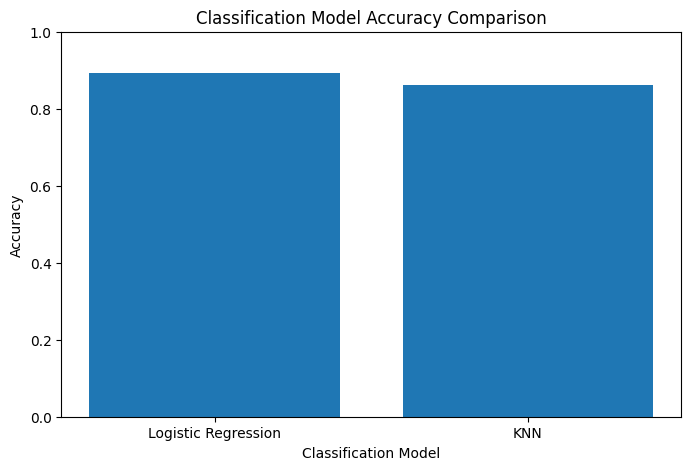

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.xlabel("Classification Model")
plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

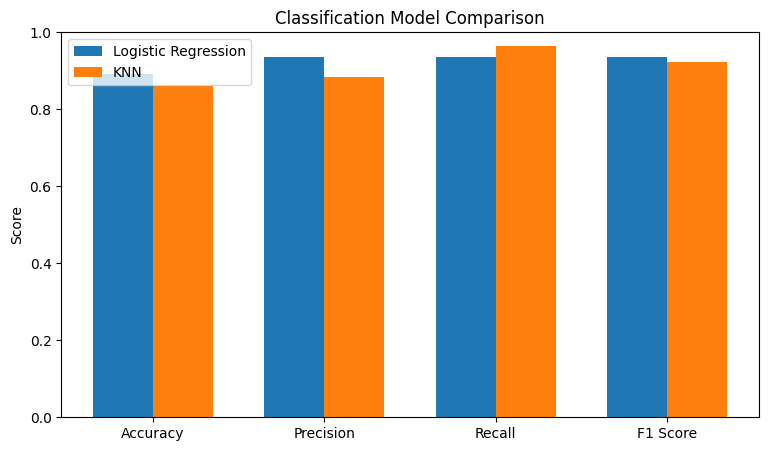

In [57]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    classification_results.iloc[0][metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    classification_results.iloc[1][metrics],
    width,
    label="KNN"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Classification Model Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

In [58]:
best_classification_model = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

print("Best Classification Model:")
print(best_classification_model)

Best Classification Model:
Model        Logistic Regression
Accuracy                0.892308
Precision               0.936364
Recall                  0.936364
F1 Score                0.936364
Name: 0, dtype: object


In [59]:
k_values = range(1, 16)
knn_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)
    knn_accuracies.append(accuracy)

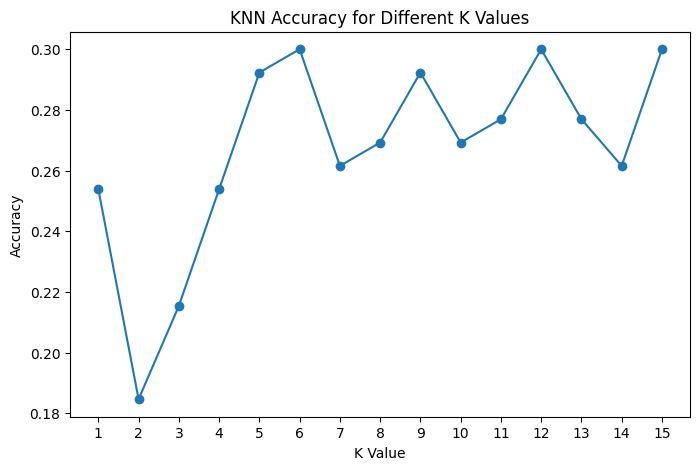

In [60]:
plt.figure(figsize=(8,5))

plt.plot(k_values, knn_accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(list(k_values))

plt.show()

In [61]:
best_k = k_values[np.argmax(knn_accuracies)]

print("Best K:", best_k)
print("Best Accuracy:", max(knn_accuracies))

Best K: 6
Best Accuracy: 0.3


In [62]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

final_knn_pred = final_knn.predict(X_test_scaled)

print("Final KNN Accuracy:",
      accuracy_score(y_test, final_knn_pred))

Final KNN Accuracy: 0.3
